# Optymalizacja hiperparametrów (HPO) z użyciem Optuna dla CatBoost na zbiorze Covertype

## Cel
Celem tego notebooka jest optymalizacja klasyfikatora CatBoost na zbiorze Covertype przy użyciu Optuna oraz porównanie jego wydajności z modelem bazowym.

W ramach zadania:
- wczytamy i przygotujemy zbiór Covertype,
- przeprowadzimy wizualizację danych,
- wytrenujemy model bazowy CatBoost,
- zoptymalizujemy hiperparametry przy użyciu Optuna,
- ocenimy model zoptymalizowany na zbiorze testowym,
- przeanalizujemy ważność cech.

In [1]:
!pip install optuna catboost pandas scikit-learn optuna-dashboard seaborn matplotlib -q

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import optuna

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

from catboost import CatBoostClassifier

## 1. Wczytanie zbioru Covertype

Zbiór Covertype to problem klasyfikacji wieloklasowej zawierający 54 cechy oraz 7 klas docelowych.

Aby skrócić czas obliczeń, wykorzystujemy stratified sample zawierający 20 000 obserwacji.

In [3]:
# Load dataset
covtype = fetch_covtype(as_frame=True)

X = covtype.data
y = covtype.target - 1  # convert labels from 1-7 to 0-6

print("Original dataset shape:")
print("X:", X.shape)
print("y:", y.shape)
print("\nClass distribution:")
print(y.value_counts().sort_index())

Original dataset shape:
X: (581012, 54)
y: (581012,)

Class distribution:
Cover_Type
0    211840
1    283301
2     35754
3      2747
4      9493
5     17367
6     20510
Name: count, dtype: int64


In [4]:
sample_size = 20000

X_sample, _, y_sample, _ = train_test_split(
    X, y,
    train_size=sample_size,
    random_state=42,
    stratify=y
)

X = X_sample
y = y_sample

print("Sampled dataset shape:")
print("X:", X.shape)
print("y:", y.shape)
print("\nSampled class distribution:")
print(y.value_counts().sort_index())

Sampled dataset shape:
X: (20000, 54)
y: (20000,)

Sampled class distribution:
Cover_Type
0    7292
1    9752
2    1231
3      94
4     327
5     598
6     706
Name: count, dtype: int64


## 2. Wizualizacja danych

Analizujemy:
- rozkład klas,
- korelacje między pierwszymi 10 cechami,
- zależności pomiędzy pierwszymi 3 cechami.

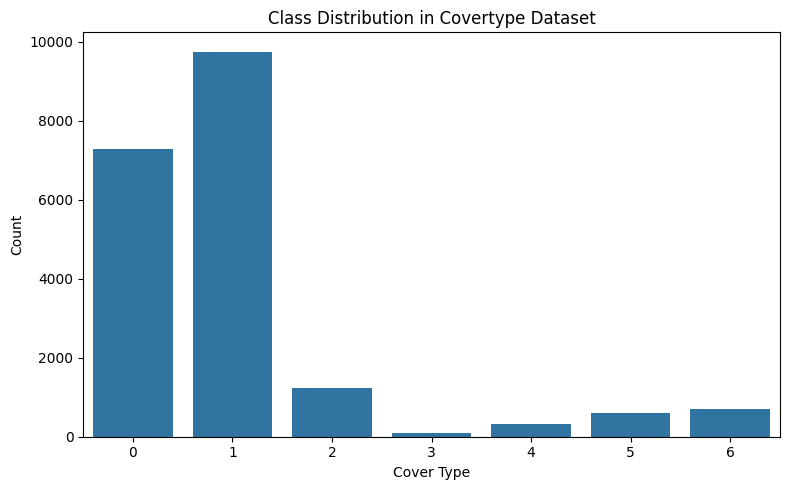

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title('Class Distribution in Covertype Dataset')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

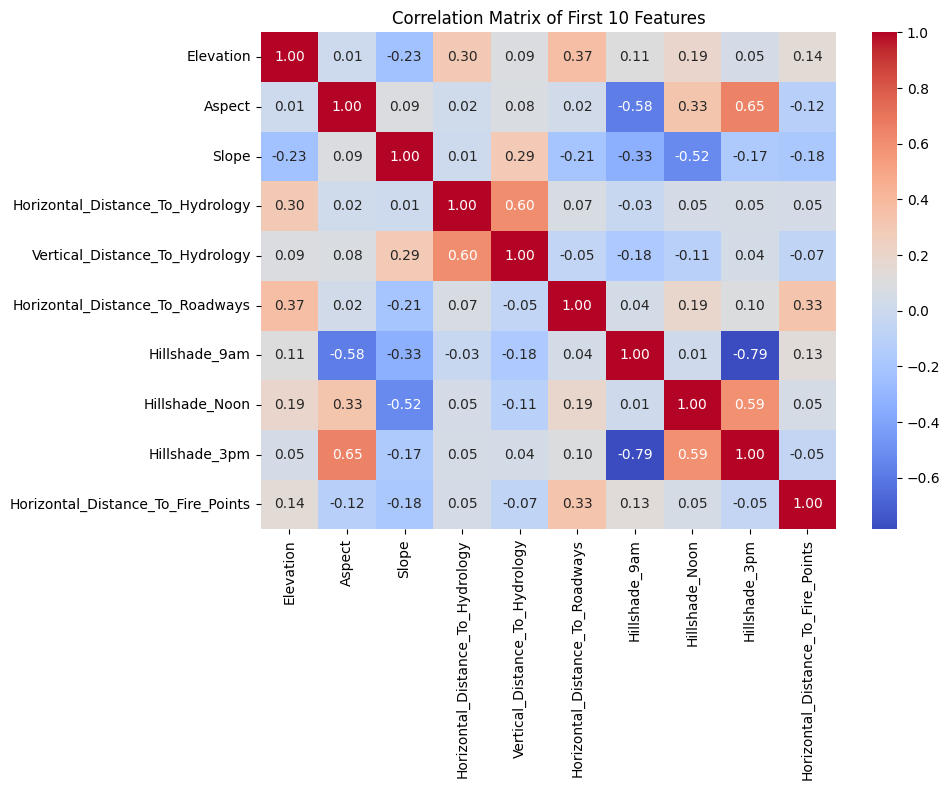

In [6]:
subset = X.iloc[:, :10]
corr = subset.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of First 10 Features')
plt.tight_layout()
plt.show()

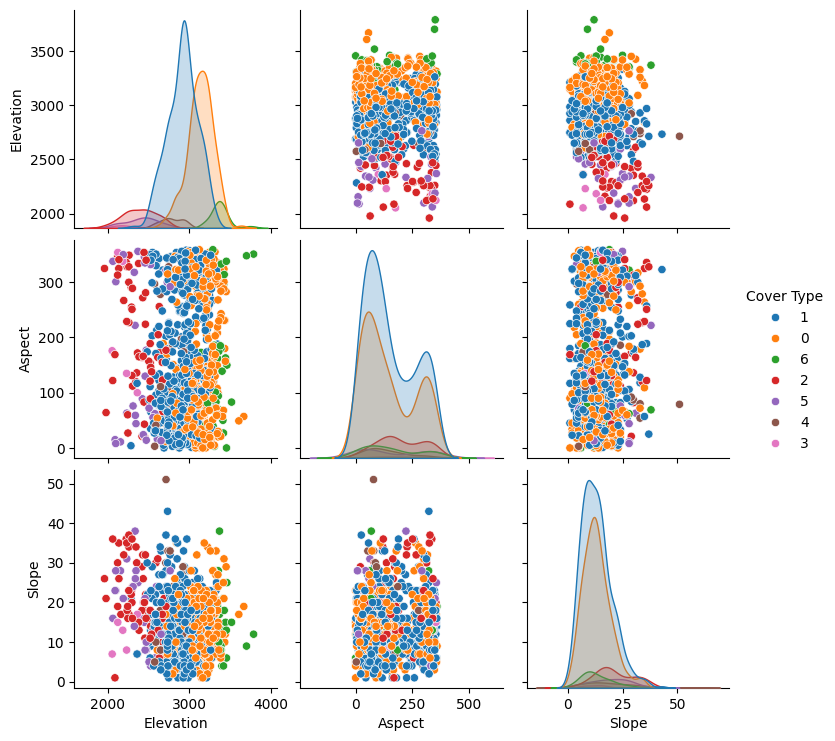

In [7]:
pairplot_sample = X.iloc[:, :3].copy()
pairplot_sample['Cover Type'] = y.astype(str)

sns.pairplot(pairplot_sample.sample(1000, random_state=42), hue='Cover Type', diag_kind='kde')
plt.show()

## 3. Podział danych: train / validation / test

Dzielimy dane na:
- zbiór treningowy,
- zbiór walidacyjny,
- zbiór testowy.

Zbiór walidacyjny będzie wykorzystywany podczas optymalizacji Optuna.

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Valid shape:", X_valid.shape, y_valid.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (14000, 54) (14000,)
Valid shape: (3000, 54) (3000,)
Test shape: (3000, 54) (3000,)


## 4. Model bazowy CatBoost

Przed rozpoczęciem optymalizacji hiperparametrów trenujemy klasyfikator CatBoost z domyślnymi ustawieniami i oceniamy jego skuteczność na zbiorze testowym.

In [9]:
baseline_model = CatBoostClassifier(
    verbose=0,
    random_state=42
)

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print(f"Baseline Accuracy: {baseline_accuracy * 100:.2f}%")

Baseline Accuracy: 83.43%


<Figure size 800x600 with 0 Axes>

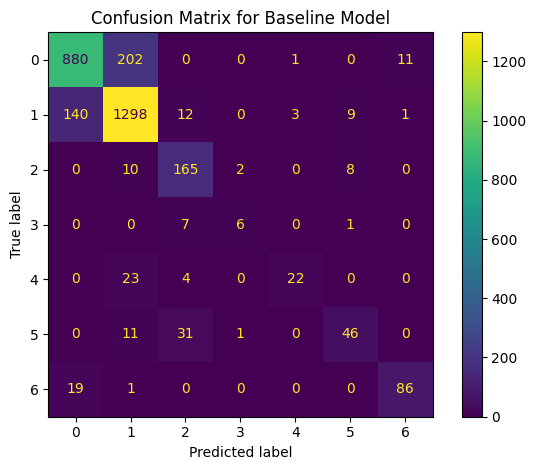

In [10]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(baseline_model, X_test, y_test)
plt.title('Confusion Matrix for Baseline Model')
plt.tight_layout()
plt.show()

## 5. Optymalizacja hiperparametrów z użyciem Optuna

Definiujemy funkcję celu, która:
- losuje hiperparametry,
- trenuje model CatBoost,
- oblicza dokładność na zbiorze walidacyjnym,
- zwraca wynik do Optuna.

In [11]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'loss_function': 'MultiClass',
        'eval_metric': 'Accuracy',
        'verbose': 0,
        'random_state': 42
    }
    
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_valid)
    acc = accuracy_score(y_valid, y_pred)
    
    return acc

In [12]:
study_name = 'catboost_optimization'
storage_name = 'sqlite:///example.db'

study = optuna.create_study(
    study_name=study_name,
    storage=storage_name,
    direction='maximize',
    load_if_exists=True
)

study.optimize(objective, n_trials=20)

[I 2026-04-21 23:42:04,653] A new study created in RDB with name: catboost_optimization
[I 2026-04-21 23:42:06,273] Trial 0 finished with value: 0.75 and parameters: {'iterations': 507, 'depth': 4, 'learning_rate': 0.02198865075680055, 'l2_leaf_reg': 1.960993358089811, 'random_strength': 2.89204414440894, 'border_count': 59}. Best is trial 0 with value: 0.75.
[I 2026-04-21 23:42:17,119] Trial 1 finished with value: 0.8403333333333334 and parameters: {'iterations': 559, 'depth': 9, 'learning_rate': 0.09304001381955099, 'l2_leaf_reg': 1.9036352388267026, 'random_strength': 0.2315645094278568, 'border_count': 36}. Best is trial 1 with value: 0.8403333333333334.
[I 2026-04-21 23:44:08,550] Trial 2 finished with value: 0.8406666666666667 and parameters: {'iterations': 905, 'depth': 10, 'learning_rate': 0.1867410800807761, 'l2_leaf_reg': 1.2664358628428158, 'random_strength': 2.999747463621358, 'border_count': 169}. Best is trial 2 with value: 0.8406666666666667.
[I 2026-04-21 23:44:17,203] 

In [13]:
best_trial = study.best_trial

print(f"Best Trial Number: {best_trial.number}")
print(f"Best Validation Accuracy: {best_trial.value:.4f}")
print("Best Hyperparameters Found:")

for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best Trial Number: 7
Best Validation Accuracy: 0.8507
Best Hyperparameters Found:
  iterations: 725
  depth: 10
  learning_rate: 0.15436884499499823
  l2_leaf_reg: 1.8001477660127752
  random_strength: 0.0025744092028851646
  border_count: 228


## 6. Omówienie wyników optymalizacji

Najlepsza próba (trial) przedstawiona powyżej pokazuje kombinację hiperparametrów, która osiągnęła najwyższą dokładność na zbiorze walidacyjnym.

Jeśli niektóre parametry znajdują się blisko granic przeszukiwanego zakresu, warto w przyszłości rozważyć jego rozszerzenie.

## 7. Trenowanie modelu końcowego

Po zakończeniu optymalizacji trenujemy model CatBoost z najlepszymi znalezionymi hiperparametrami na połączonym zbiorze treningowym i walidacyjnym.

Pozwala to modelowi uczyć się na większej ilości danych przed ostateczną ewaluacją.

In [14]:
X_train_full = pd.concat([X_train, X_valid], ignore_index=True)
y_train_full = pd.concat([y_train, y_valid], ignore_index=True)

best_params = best_trial.params.copy()
best_params['random_state'] = 42
best_params['verbose'] = 0
best_params['loss_function'] = 'MultiClass'
best_params['eval_metric'] = 'Accuracy'

final_model = CatBoostClassifier(**best_params)
final_model.fit(X_train_full, y_train_full)

CatBoostClassifier(border_count=228, depth=10, eval_metric='Accuracy', iterations=725, l2_leaf_reg=1.8001477660127752, learning_rate=0.15436884499499823, loss_function='MultiClass', random_state=42, random_strength=0.0025744092028851646, verbose=0)

In [15]:
y_pred_test = final_model.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred_test)

print("--- Performance Comparison ---")
print(f"Baseline Accuracy (on Test Set): {baseline_accuracy * 100:.2f}%")
print(f"Optimized Accuracy (on Test Set): {final_accuracy * 100:.2f}%")

improvement = final_accuracy - baseline_accuracy
print(f"Improvement due to HPO: {improvement * 100:.2f}%")

--- Performance Comparison ---
Baseline Accuracy (on Test Set): 83.43%
Optimized Accuracy (on Test Set): 86.07%
Improvement due to HPO: 2.63%


<Figure size 800x600 with 0 Axes>

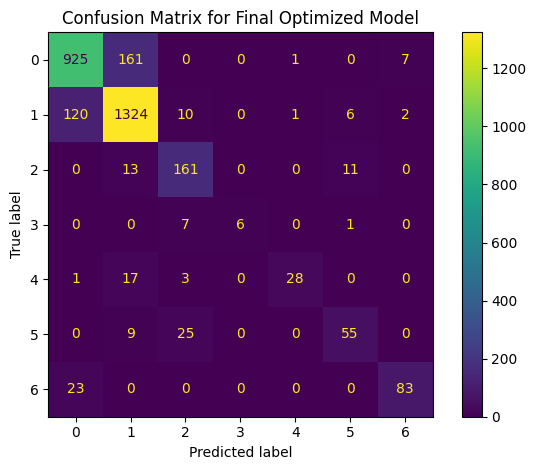

In [16]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title('Confusion Matrix for Final Optimized Model')
plt.tight_layout()
plt.show()

## 8. Analiza ważności cech

Na końcu analizujemy, które cechy były najważniejsze dla modelu CatBoost podczas podejmowania decyzji.

In [17]:
importances = final_model.get_feature_importance()
feature_names = X_train_full.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(20)

,Feature,Importance
0,Elevation,22.343010
5,Horizontal_Distance_To_Roadways,12.871583
9,Horizontal_Distance_To_Fire_Points,12.395715
3,Horizontal_Distance_To_Hydrology,8.663750
4,Vertical_Distance_To_Hydrology,7.073253
7,Hillshade_Noon,5.901598
6,Hillshade_9am,5.605999
1,Aspect,5.371459
2,Slope,4.594214
12,Wilderness_Area_2,3.635967


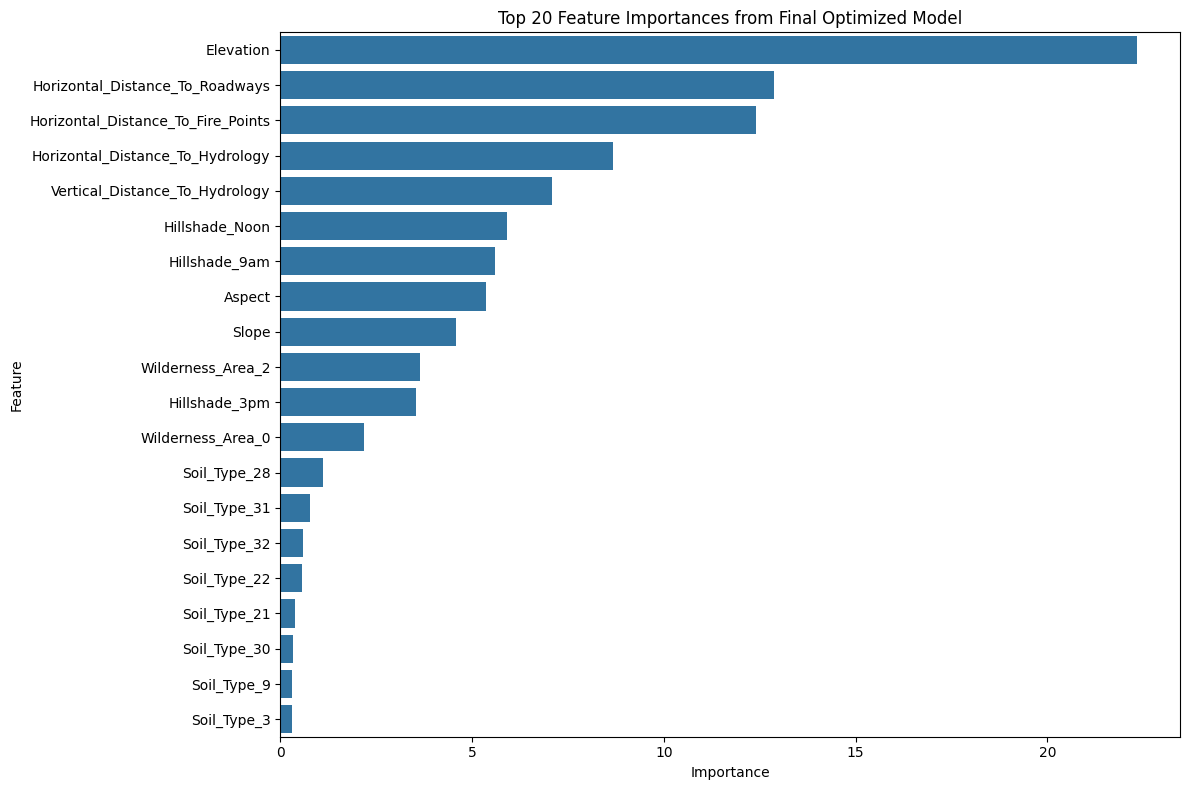

In [18]:
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df.head(20)
)
plt.title('Top 20 Feature Importances from Final Optimized Model')
plt.tight_layout()
plt.show()

## 9. Podsumowanie i wnioski ogólne

W tym notebooku:
- wytrenowano model bazowy CatBoost,
- zoptymalizowano jego hiperparametry przy użyciu Optuna (20 prób),
- ponownie wytrenowano model na połączonych danych treningowych i walidacyjnych,
- oceniono jego skuteczność na zbiorze testowym,
- przeanalizowano ważność cech.

### Porównanie modeli

Na podstawie macierzy pomyłek oraz wyników Optuna:

- Najlepszy wynik walidacyjny osiągnął model: **85.07% accuracy**
- Optymalizacja hiperparametrów poprawiła jakość modelu względem baseline’u

Największe zmiany po optymalizacji:
- lepsza klasyfikacja klasy **0** (880 → 925 poprawnych predykcji),
- poprawa dla klasy **1** (1298 → 1324),
- poprawa dla klasy **5** (46 → 55),
- niewielkie pogorszenie dla klasy **2** i **6**.

### Analiza macierzy pomyłek

Model najczęściej myli:
- klasę **0 z 1** (dużo błędów w obu kierunkach),
- klasę **5 z 2**,
- klasę **6 z 0**.

Po optymalizacji:
- liczba błędów między klasami 0 i 1 zmniejszyła się,
- model lepiej rozróżnia klasy dominujące,
- nadal występują trudności w rozróżnianiu klas o podobnych cechach.

### Najlepsze hiperparametry

Najlepszy model używał m.in.:
- dużej głębokości drzew (`depth = 10`),
- wysokiej liczby iteracji (`iterations ≈ 725`),
- stosunkowo dużego learning rate (`~0.15`),
- bardzo niskiego `random_strength`.

Może to sugerować, że:
- model korzysta z bardziej złożonych drzew,
- dane wymagają większej ekspresyjności modelu,
- lekkie ograniczenie losowości poprawia stabilność.

### Najważniejsze cechy

Największy wpływ na predykcję miały:

- **Elevation** (zdecydowanie najważniejsza),
- **Horizontal_Distance_To_Roadways**
- **Horizontal_Distance_To_Fire_Points**
- **Horizontal_Distance_To_Hydrology**
- **Vertical_Distance_To_Hydrology**

Interpretacja:
- typ pokrycia terenu silnie zależy od wysokości i odległości od elementów środowiska,
- cechy geograficzne są kluczowe,
- cechy typu *Soil_Type* mają znacznie mniejsze znaczenie.